In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

DIR = '/content/drive/MyDrive/table3'
!mkdir -p {DIR}

print("Select table3_extract_v2.py and table3_analyze.py:")
uploaded = files.upload()          # file picker opens

!cp *.py {DIR}/                    # also save to Drive for next time
!pip install -q transformers accelerate tqdm scikit-learn matplotlib

import os
print([f for f in os.listdir('.') if f.endswith('.py')])

Mounted at /content/drive
Select table3_extract_v2.py and table3_analyze.py:


Saving table3_analyze.py to table3_analyze.py
Saving table3_extract_v2.py to table3_extract_v2.py
['table3_analyze.py', 'table3_extract_v2.py']


In [ ]:
from huggingface_hub import login
login('HF_TOKEN')

In [ ]:
from huggingface_hub import whoami
print(whoami()["name"])

divyaaa-pa-ndy-yaa


In [ ]:
!python table3_extract_v2.py --model google/gemma-2-2b --smoke

20 concepts, 2400 prompts (4 families x 5 x 24 queries x 5 shot counts)

--- sample prompt ---
tzirwzt -> blicket
ebcwrvm ->

row: {'concept_idx': 0, 'concept_id': 'single_my_nb', 'family': 'single', 'k': 1, 'test_idx': 0, 'query': 'ebcwrvm', 'label': 0}

label balance: [1200 1200]
families: {np.str_('conjunctive'): np.int64(600), np.str_('disjunctive'): np.int64(600), np.str_('negation'): np.int64(600), np.str_('single'): np.int64(600)}


In [ ]:
!python table3_extract_v2.py --model google/gemma-2-2b \
    --out-dir /content/drive/MyDrive/table3_gemma2b

20 concepts, 2400 prompts (4 families x 5 x 24 queries x 5 shot counts)
loading google/gemma-2-2b on cuda
config.json: 100% 818/818 [00:00<00:00, 2.78MB/s]
tokenizer_config.json: 100% 46.4k/46.4k [00:00<00:00, 67.6MB/s]

tokenizer.json: downloading bytes:   0% 0.00/17.5M [00:00<?, ?B/s]
tokenizer.json: downloading bytes: 100% 7.50M/7.50M [00:01<00:00, 7.04MB/s,  733kB/s  ]
tokenizer.json: reconstructing file: 100% 17.5M/17.5M [00:01<00:00, 16.5MB/s, 1.71MB/s  ]
special_tokens_map.json: 100% 636/636 [00:00<00:00, 3.06MB/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors.index.json: 100% 24.2k/24.2k [00:00<00:00, 51.1MB/s]
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0% 0/3 [00:00<?, ?it/s]
Reconstructing (incomplete total...):   0% 0.00/5.47G [00:00<?, ?B/s]         
Reconstructing (incomplete total...):   0% 0.00/10.5G [00:00<?, ?B/s]
Reconstructing (incomplete total...):   7% 738M/10.5G [00:10<03

In [ ]:
!mkdir -p /content/drive/MyDrive/table3_gemma2b
!python table3_extract_v2.py --model google/gemma-2-2b \
    --out-dir /content/drive/MyDrive/table3_gemma2b

20 concepts, 2400 prompts (4 families x 5 x 24 queries x 5 shot counts)
loading google/gemma-2-2b on cuda
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 288/288 [00:32<00:00,  8.96it/s]
class label token ids: [111651, 499] ([' blick', ' d'])
extracting: 100% 150/150 [01:48<00:00,  1.39it/s]

saved -> activations(2400, 27, 2304), rows.json, concepts.json

BEHAVIORAL ACCURACY (chance 50%)
   1-shot:  49.8%
   2-shot:  49.8%
   4-shot:  53.8%
   8-shot:  55.0%
  16-shot:  61.3%
  by family:
    single      :  53.3%
    conjunctive :  57.2%
    disjunctive :  49.0%
    negation    :  56.2%
  overall: 53.9%

  [!] At or near chance. If the model cannot learn the rule behaviorally,
      there is no acquired concept for Table 3 to localise. That is a
      finding, but it changes what the probe result means -- discuss
      with Gautam before building on it.


In [ ]:
D = '/content/drive/MyDrive/table3_gemma2b'
!python table3_analyze.py --acts {D}/activations.npy --rows {D}/rows.json \
    --out {D}/table3_row.json --model-name Gemma-2-2B

2400 rows, 27 layers, hidden 2304, 20 concepts, label balance [1200 1200]

behavioral accuracy: 53.9% (chance 50%)
   1-shot:  49.8%
   2-shot:  49.8%
   4-shot:  53.8%
   8-shot:  55.0%
  16-shot:  61.3%
  conjunctive :  57.2%
  disjunctive :  49.0%
  negation    :  56.2%
  single      :  53.3%

  [!] Behavior at/near chance. A strong probe here would mean
      the rule is encoded but NOT USED -- a different claim
      than H2 makes. Flag before writing this up.

[transfer] train 1800 / test 600 (5 held-out concepts)
transfer: 100% 27/27 [00:47<00:00,  1.77s/it]
null: 100% 20/20 [05:38<00:00, 16.91s/it]
  null 49.7% +/- 0.5  thresh 59.7%
  peak 64.7% @ L17  L_E=12  L_S=None

[item] train 1100 / test 1300
item: 100% 27/27 [00:26<00:00,  1.03it/s]
null: 100% 20/20 [03:18<00:00,  9.93s/it]
  null 50.0% +/- 0.7
  peak 69.5% @ L13  L_E=6  L_S=8

[by shot count, transfer split]
k=1: 100% 27/27 [00:12<00:00,  2.16it/s]
  k= 1: peak  56.7% @ L14
k=2: 100% 27/27 [00:10<00:00,  2.49it/s]
  k=

In [ ]:
import json, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

D = '/content/drive/MyDrive/table3_gemma2b'
acts = np.load(f'{D}/activations.npy')
rows = json.loads(open(f'{D}/rows.json').read())
y   = np.array([r['label'] for r in rows])
fam = np.array([r['family'] for r in rows])

def probe(L, labels, tr, te):
    X = acts[:, L, :].astype(np.float32)
    sc = StandardScaler().fit(X[tr])
    clf = LogisticRegression(max_iter=2000, C=0.1).fit(sc.transform(X[tr]), labels[tr])
    return clf.score(sc.transform(X[te]), labels[te])

print("FAMILY HOLDOUT — Gemma-2-2B\n")
peaks = {}
for held in sorted(set(fam)):
    te, tr = fam == held, fam != held
    a = np.array([probe(L, y, tr, te) for L in range(acts.shape[1])])
    peaks[held] = float(a.max())
    print(f"  held out {held:12s}: peak {100*a.max():5.1f}% @ L{int(a.argmax())}")

rng = np.random.RandomState(0)
held = sorted(set(fam))[0]
te, tr = fam == held, fam != held
null_runs = []
for _ in range(10):
    ys = rng.permutation(y)
    null_runs.append(np.mean([probe(L, ys, tr, te) for L in range(0, acts.shape[1], 6)]))
null = float(np.mean(null_runs))

print(f"\n  permutation null: {100*null:.1f}%")
print(f"  mean peak: {100*np.mean(list(peaks.values())):.1f}%")
json.dump({'peaks': peaks, 'null': null}, open(f'{D}/family_holdout.json','w'))

FAMILY HOLDOUT — Gemma-2-2B

  held out conjunctive : peak  68.3% @ L21
  held out disjunctive : peak  63.8% @ L15
  held out negation    : peak  64.7% @ L17
  held out single      : peak  67.7% @ L15

  permutation null: 49.2%
  mean peak: 66.1%


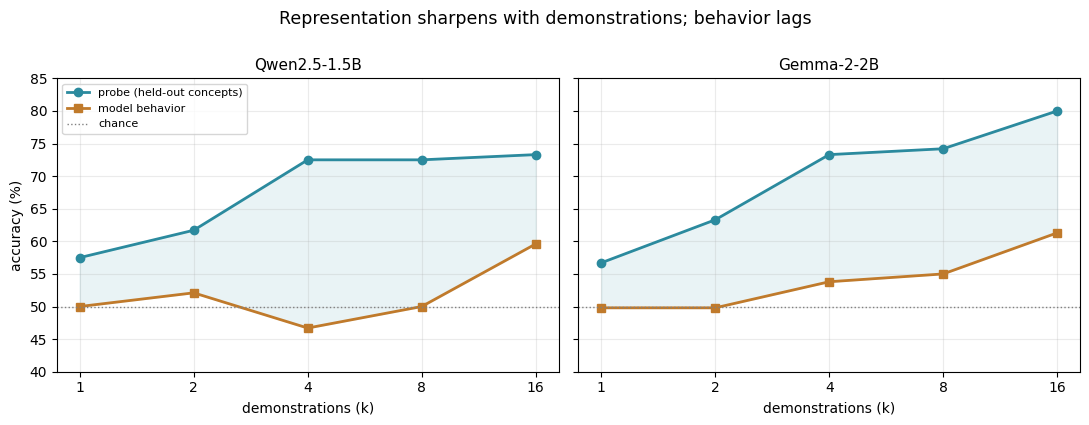


| | Qwen2.5-1.5B | Gemma-2-2B |
|---|---|---|
| Probe accuracy (transfer) | 66.2% | 64.7% |
| Peak layer | 15 of 28 | 17 of 26 |
| L_E (raw / % depth) | 5  (17%) | 12  (44%) |
| L_S | none | none |
| Permutation null | 50.2% | 49.7% |
| Behavior, overall | 51.7% | 53.9% |
| Behavior, 16-shot | 59.6% | 61.3% |
| Probe, 16-shot | 73.3% | 80.0% |
| Item split peak | 65.8% | 69.5% |
| Family holdout mean | 66.8% | pending |

saved -> /content/drive/MyDrive/table3_comparison/dissociation.png, comparison.md


In [ ]:
import matplotlib.pyplot as plt
import numpy as np, json, os

OUT = '/content/drive/MyDrive/table3_comparison'
os.makedirs(OUT, exist_ok=True)
SHOTS = [1, 2, 4, 8, 16]

M = {
 'Qwen2.5-1.5B': dict(probe=[57.5,61.7,72.5,72.5,73.3], behav=[50.0,52.1,46.7,50.0,59.6],
                      peak=66.2, peak_L=15, L_E=5, n_layers=29, null=50.2,
                      item_peak=65.8, item_L_E=3, item_L_S=7, overall=51.7, fam_mean=66.8),
 'Gemma-2-2B':   dict(probe=[56.7,63.3,73.3,74.2,80.0], behav=[49.8,49.8,53.8,55.0,61.3],
                      peak=64.7, peak_L=17, L_E=12, n_layers=27, null=49.7,
                      item_peak=69.5, item_L_E=6, item_L_S=8, overall=53.9, fam_mean=None),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (name, d) in zip(axes, M.items()):
    x = range(len(SHOTS))
    ax.plot(x, d['probe'], 'o-', color='#2b8a9e', lw=2, label='probe (held-out concepts)')
    ax.plot(x, d['behav'], 's-', color='#c07a2b', lw=2, label='model behavior')
    ax.fill_between(x, d['behav'], d['probe'], color='#2b8a9e', alpha=.10)
    ax.axhline(50, ls=':', c='gray', lw=1, label='chance')
    ax.set_xticks(list(x)); ax.set_xticklabels(SHOTS)
    ax.set_xlabel('demonstrations (k)'); ax.set_title(name, fontsize=11)
    ax.grid(alpha=.25); ax.set_ylim(40, 85)
axes[0].set_ylabel('accuracy (%)'); axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Representation sharpens with demonstrations; behavior lags',
             fontsize=12.5, y=1.00)
plt.tight_layout(); plt.savefig(f'{OUT}/dissociation.png', dpi=180, bbox_inches='tight')
plt.show()

rows = [
 ('Probe accuracy (transfer)', '66.2%', '64.7%'),
 ('Peak layer',                '15 of 28', '17 of 26'),
 ('L_E (raw / % depth)',       '5  (17%)', '12  (44%)'),
 ('L_S',                       'none', 'none'),
 ('Permutation null',          '50.2%', '49.7%'),
 ('Behavior, overall',         '51.7%', '53.9%'),
 ('Behavior, 16-shot',         '59.6%', '61.3%'),
 ('Probe, 16-shot',            '73.3%', '80.0%'),
 ('Item split peak',           '65.8%', '69.5%'),
 ('Family holdout mean',       '66.8%', 'pending'),
]
md = '| | Qwen2.5-1.5B | Gemma-2-2B |\n|---|---|---|\n'
md += '\n'.join(f'| {a} | {b} | {c} |' for a,b,c in rows)
open(f'{OUT}/comparison.md','w').write(md)
print('\n' + md)
print(f'\nsaved -> {OUT}/dissociation.png, comparison.md')

In [ ]:
md = open('/content/drive/MyDrive/table3_comparison/comparison.md').read()
md = md.replace('| 66.8% | pending |', '| 66.8% | 66.1% |')
open('/content/drive/MyDrive/table3_comparison/comparison.md','w').write(md)
print(md)

| | Qwen2.5-1.5B | Gemma-2-2B |
|---|---|---|
| Probe accuracy (transfer) | 66.2% | 64.7% |
| Peak layer | 15 of 28 | 17 of 26 |
| L_E (raw / % depth) | 5  (17%) | 12  (44%) |
| L_S | none | none |
| Permutation null | 50.2% | 49.7% |
| Behavior, overall | 51.7% | 53.9% |
| Behavior, 16-shot | 59.6% | 61.3% |
| Probe, 16-shot | 73.3% | 80.0% |
| Item split peak | 65.8% | 69.5% |
| Family holdout mean | 66.8% | 66.1% |
